<a href="https://colab.research.google.com/github/Subah-Zarin/Wall-Decoration-Pattern-Analysis-/blob/main/text_and_metadata_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Embeddings + Event Metadata Extraction

Two non-training, inference-only steps that run in parallel with the color-palette baseline:

1. **Text embeddings** — encode `combined_description` (English+Bengali) into vectors using a
   pretrained multilingual sentence encoder (LaBSE). Cached the same way as the DINOv2 image
   embeddings, for reuse in Phase 10's retrieval-based recommender.
2. **Event-type metadata extraction** — your annotation schema has no structured `event_type`
   column, but event/occasion context is clearly present in the captions (Bengali New Year,
   cricket league, programming contest, etc.). This derives a starting `event_type` tag per image
   via keyword matching, as a bootstrap until it's collected directly during future annotation.

⚠️ **Do not use these caption embeddings as input features for `wall_type`/`color_idea`
classifiers** — captions describe those labels directly, so that would leak the answer into the
input. These are for retrieval/recommendation and dataset exploration only.

> Run in Colab. No GPU strictly required (LaBSE is small enough for CPU, but GPU is faster).


In [1]:
# ============================================================
# 1. INSTALL + IMPORTS
# ============================================================

!pip -q install sentence-transformers pandas numpy scikit-learn matplotlib

import os
import re
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cpu


In [2]:
# ============================================================
# 2. CONFIG
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

SPLITS_FOLDER = "/content/drive/MyDrive/Campus_Wall_Preprocessing"
OUTPUT_FOLDER = "/content/drive/MyDrive/SoftCom Project/Dataset/Text_Metadata_Results"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# LaBSE: supports 109 languages including Bengali, trained specifically for cross-lingual
# semantic alignment -- an English query and its Bengali translation land close together.
TEXT_MODEL_NAME = "sentence-transformers/LaBSE"


Mounted at /content/drive


## Load full dataset

This step works over the full pool (train+validation+test combined) since it's feature
extraction / metadata derivation, not a classification experiment with a held-out test set.


In [3]:
# ============================================================
# 3. LOAD SPLITS
# ============================================================

def load_split(name):
    path = os.path.join(SPLITS_FOLDER, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find {path}\nCheck SPLITS_FOLDER in the CONFIG cell.")
    return pd.read_csv(path, encoding="utf-8-sig")

full_df = pd.concat(
    [load_split("train.csv"), load_split("validation.csv"), load_split("test.csv")],
    ignore_index=True,
).drop_duplicates(subset="image_id").reset_index(drop=True)

print("Total images:", len(full_df))
print(full_df[["image_id", "wall_type", "combined_description"]].head(3))


Total images: 204
    image_id     wall_type                               combined_description
0  image_002    brick_wall  Campus wall decorated with a football player, ...
1  image_004  painted_wall  Campus wall decorated with Alpana, traditional...
2  image_005   wooden_wall  Campus wall decorated with traditional masks, ...


## Part A — Text embeddings (LaBSE)

`combined_description` already concatenates the English and Bengali descriptions in your CSVs --
embedding it directly gives one vector per image that captures both languages' content.


In [4]:
# ============================================================
# 4. EXTRACT + CACHE TEXT EMBEDDINGS
# ============================================================

text_model = SentenceTransformer(TEXT_MODEL_NAME, device=DEVICE)

captions = full_df["combined_description"].fillna("").tolist()
text_embeddings = text_model.encode(
    captions, batch_size=16, show_progress_bar=True, normalize_embeddings=True
)

print("Text embedding matrix:", text_embeddings.shape)

np.savez(
    os.path.join(OUTPUT_FOLDER, "caption_embeddings_labse.npz"),
    image_ids=full_df["image_id"].values,
    embeddings=text_embeddings,
)
print("Cached ->", os.path.join(OUTPUT_FOLDER, "caption_embeddings_labse.npz"))
print("To reuse later:  data = np.load(path); ids = data['image_ids']; X = data['embeddings']")


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/2.02k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors: reconstructing file:   0%|          |  0.00B / 2.36MB            

2_Dense/model.safetensors: downloading bytes:           |  0.00B            

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Text embedding matrix: (204, 768)
Cached -> /content/drive/MyDrive/SoftCom Project/Dataset/Text_Metadata_Results/caption_embeddings_labse.npz
To reuse later:  data = np.load(path); ids = data['image_ids']; X = data['embeddings']


## Sanity check — nearest-caption retrieval

This is the exact operation Phase 10's retrieval-based recommender will run: given a query
(an event description or another image's caption), find the closest existing decorations by
semantic similarity. Try changing `query_text` below.


In [5]:
# ============================================================
# 5. RETRIEVAL DEMO
# ============================================================

def retrieve_similar_captions(query_text, top_k=5):
    query_vec = text_model.encode([query_text], normalize_embeddings=True)
    similarities = text_embeddings @ query_vec.T  # cosine similarity (embeddings are normalized)
    similarities = similarities.flatten()
    top_idx = np.argsort(-similarities)[:top_k]
    for idx in top_idx:
        row = full_df.iloc[idx]
        print(f"[{similarities[idx]:.3f}] {row['image_id']} ({row['wall_type']}): "
              f"{row['description_en'][:100]}...")

retrieve_similar_captions("decoration for a cricket tournament")
print()
retrieve_similar_captions("বাংলা নববর্ষের সাজসজ্জা")  # "Bengali New Year decoration" query in Bengali


[0.464] image_162 (brick_wall): Campus wall decorated with a handmade cricket-themed poster on chart paper for a sports event, featu...
[0.460] image_161 (brick_wall): Campus wall decorated for a cricket tournament, featuring team group assignments, team logos, and il...
[0.458] image_142 (painted_wall): Indoor display board decorated for a sports event, featuring an inspirational motivational quote at ...
[0.452] image_001 (brick_wall): Campus wall decorated with a championship trophy, cricket-themed banners, celebratory graphics, and ...
[0.419] image_011 (brick_wall): Decoration for a cricket league event. Components used include a central event banner, paper cutouts...

[0.562] image_004 (painted_wall): Campus wall decorated with Alpana, traditional artwork, colorful motifs, and Bengali New Year decora...
[0.530] image_005 (wooden_wall): Campus wall decorated with traditional masks, hand fans, dhol, colorful cultural ornaments, and Beng...
[0.529] image_177 (bulletin_board): Campus

## Part B — Event-type metadata extraction

Keyword-based bootstrap tagging from `combined_description`. **This is a heuristic starting
point, not ground truth** — review the output, correct misclassifications, and treat this as a
first pass to speed up manually adding a proper `event_type` field. Extend `EVENT_KEYWORDS` with
terms specific to your dataset as you review results.


In [6]:
# ============================================================
# 6. KEYWORD-BASED EVENT TAGGING
# ============================================================

# Starting categories, inferred from patterns already visible in your captions.
# Add/adjust freely -- this is meant to be edited as you review the tagged output.
EVENT_KEYWORDS = {
    "cultural_heritage": [
        "bengali new year", "alpana", "pohela boishakh", "amar ekushey",
        "language movement", "traditional", "cultural", "heritage", "folk",
    ],
    "sports": [
        "football", "cricket", "sports day", "trophy", "athlete", "tournament",
        "match", "championship", "batsman", "player",
    ],
    "tech_academic": [
        "programming contest", "circuit", "binary code", "hackathon", "seminar",
        "conference", "workshop", "academic", "science",
    ],
    "welcome_orientation": [
        "welcome", "orientation", "freshers", "farewell", "greeting",
    ],
    "general_festive": [
        "balloon", "floral", "celebration", "festive", "party", "anniversary",
    ],
}

def extract_event_tags(text):
    text_lower = str(text).lower()
    matched = [
        category for category, keywords in EVENT_KEYWORDS.items()
        if any(kw in text_lower for kw in keywords)
    ]
    return matched if matched else ["unclassified"]

full_df["event_type_inferred"] = full_df["combined_description"].apply(extract_event_tags)

# Distribution
from collections import Counter
tag_counts = Counter(tag for tags in full_df["event_type_inferred"] for tag in tags)
print("Inferred event_type distribution:")
for tag, count in tag_counts.most_common():
    print(f"  {tag:20s} {count}")

unclassified_count = sum(1 for tags in full_df['event_type_inferred'] if tags == ['unclassified'])
print(f"\n{unclassified_count}/{len(full_df)} images unclassified -- inspect these and extend EVENT_KEYWORDS.")


Inferred event_type distribution:
  unclassified         68
  general_festive      53
  cultural_heritage    45
  sports               42
  welcome_orientation  21
  tech_academic        8

68/204 images unclassified -- inspect these and extend EVENT_KEYWORDS.


In [7]:
# ============================================================
# 7. INSPECT UNCLASSIFIED / BORDERLINE ROWS
# ============================================================

unclassified_df = full_df[full_df["event_type_inferred"].apply(lambda t: t == ["unclassified"])]
pd.set_option("display.max_colwidth", 150)
display(unclassified_df[["image_id", "wall_type", "description_en"]])


,image_id,wall_type,description_en
14,image_018,brick_wall,Wall display showcasing group study tour memory photographs. Components used include five printed group tour photos arranged in a cross layout alo...
17,image_021,brick_wall,"Memory photo display wall for a student batch milestone with batch name in cutout letters. Components used include white 3D title text, multiple g..."
28,image_041,painted_wall,Art and Craft Exhibition photo booth backdrop setup. Components used include a white fabric backdrop bearing glittery text 'ART & CRAFT EXHIBITION...
39,image_057,backdrop_board,Vibrant photo backdrop curtain with paper fan flower rosettes. Components used include a wide curtain of closely spaced vertical crepe paper strea...
41,image_061,painted_wall,'Photo booth backdrop setup for First Report Card Day'. Components used include a large archway made of multi-colored paper fan rosettes in rainbo...
...,...,...,...
192,image_054,painted_wall,Decorative display wall setup for 'Pitha Utsab 2017' (Bengali Cake Festival). Components used include bamboo winnowing trays (kula) carrying black...
196,image_074,backdrop_board,"An elegant photo backdrop setup featuring draped white fabric curtains topped with an arch of accordion paper fan rosettes in black, metallic gold..."
198,image_097,brick_wall,"A Mother's Day bulletin board set around a red brick pillar, featuring giant paper cutouts of hands holding white daisy flowers, and a yellow bann..."
199,image_149,painted_wall,"Indoor photobooth frame board designed for a video production or movie-themed event, featuring text reading ""VIDEO PRODUCTION"" and ""LIGHTS CAMERA ..."


## Save the enriched metadata

Merges the original annotation columns with the new `event_type_inferred` tag, ready to
join with the cached image (DINOv2) and text (LaBSE) embeddings for Phase 10.


In [8]:
# ============================================================
# 8. SAVE ENRICHED METADATA
# ============================================================

output_columns = ["image_id", "wall_type", "indoor", "color_idea",
                   "event_type_inferred", "description_en", "description_bn", "group_id"]
enriched_df = full_df[[c for c in output_columns if c in full_df.columns]].copy()
enriched_df["event_type_inferred"] = enriched_df["event_type_inferred"].apply(lambda t: ",".join(t))

enriched_path = os.path.join(OUTPUT_FOLDER, "metadata_with_event_tags.csv")
enriched_df.to_csv(enriched_path, index=False, encoding="utf-8-sig")
print("Saved ->", enriched_path)
display(enriched_df.head())


Saved -> /content/drive/MyDrive/SoftCom Project/Dataset/Text_Metadata_Results/metadata_with_event_tags.csv


,image_id,wall_type,indoor,color_idea,event_type_inferred,description_en,description_bn,group_id
0,image_002,brick_wall,1,"black,white,gold",sports,"Campus wall decorated with a football player, football-themed graphics, trophies, motivational quotes, emojis, letters, and sports-related decorat...","ফুটবল খেলোয়াড়ের ছবি, ফুটবল-থিমযুক্ত গ্রাফিক্স, ট্রফি, অনুপ্রেরণামূলক উক্তি, ইমোজি, অক্ষর ও খেলাধুলা-সম্পর্কিত সাজসজ্জায় সজ্জিত ক্যাম্পাসের দেয়াল।",group_002
1,image_004,painted_wall,1,"red,white,green",cultural_heritage,"Campus wall decorated with Alpana, traditional artwork, colorful motifs, and Bengali New Year decorations.","আলপনা, লোকজ শিল্প, রঙিন নকশা ও বাংলা নববর্ষের সাজসজ্জায় সজ্জিত ক্যাম্পাসের দেয়াল।",group_002
2,image_005,wooden_wall,0,"red,white",cultural_heritage,"Campus wall decorated with traditional masks, hand fans, dhol, colorful cultural ornaments, and Bengali New Year motifs.","ঐতিহ্যবাহী মুখোশ, হাতপাখা, ঢোল, রঙিন সাংস্কৃতিক অলংকার ও বাংলা নববর্ষের নকশায় সজ্জিত ক্যাম্পাসের দেয়াল।",group_002
3,image_006,painted_wall,1,"yellow,orange,red,black","welcome_orientation,general_festive",A colorful floral wall decoration with a welcome message made from handmade paper flowers,হাতে তৈরি রঙিন কাগজের ফুল দিয়ে সাজানো স্বাগতম বার্তাসহ দেয়ালসজ্জা,group_003
4,image_007,bulletin_board,1,"black,white","cultural_heritage,general_festive",A black decorative photo frame with red and white paper flowers for Amar Ekushey celebration.,অমর একুশে উপলক্ষে লাল-সাদা কাগজের ফুল দিয়ে সাজানো কালো ফটো ফ্রেম,group_004


## Optional — visualize caption embeddings by inferred event type

A quick 2D projection to sanity-check whether the keyword tags line up with actual semantic
clusters in the embedding space. If a category's points are scattered randomly rather than
grouped, its keyword list probably needs refining.


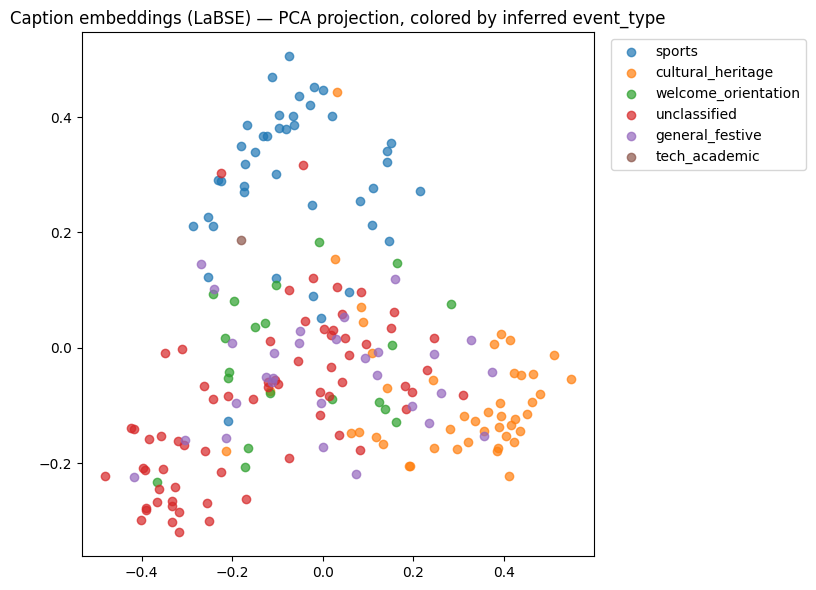

In [9]:
# ============================================================
# 9. VISUALIZE CAPTION EMBEDDING CLUSTERS
# ============================================================

pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(text_embeddings)

primary_tag = full_df["event_type_inferred"].apply(lambda t: t[0])
plt.figure(figsize=(8, 6))
for tag in primary_tag.unique():
    mask = primary_tag == tag
    plt.scatter(coords_2d[mask, 0], coords_2d[mask, 1], label=tag, alpha=0.7)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("Caption embeddings (LaBSE) — PCA projection, colored by inferred event_type")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "caption_embedding_clusters.png"), dpi=150)
plt.show()


## Outputs saved

Under `OUTPUT_FOLDER`:
- **`caption_embeddings_labse.npz`** — per-image bilingual caption embeddings, reusable for Phase 10 retrieval.
- **`metadata_with_event_tags.csv`** — original metadata + bootstrap `event_type_inferred` column.
- `caption_embedding_clusters.png` — sanity-check visualization.

## Next steps
1. Manually review `metadata_with_event_tags.csv`, especially the `unclassified` rows and any category with the keyword list still short — correct/expand as needed. This becomes your real `event_type` ground truth.
2. Add an explicit `event_type` field to your annotation process for new images going forward, so future data doesn't need this bootstrap step at all.
3. Once `event_type` is reasonably clean, it becomes the "event" half of Phase 10's retrieval-based recommender: given a new wall + event_type, retrieve the closest past decoration by combining the DINOv2 image embedding and LaBSE caption embedding.
4. Keep `caption_embeddings_labse.npz` and `dinov2_embeddings_*.npz` as your two core cached feature stores -- everything from Phase 6 onward should read from these rather than recomputing.
